In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

In [39]:
# Filterring for India and removing any rows with missing values in the 'salary_year_avg' column
df_India = df[df['job_country'] == 'India'].dropna(subset=['salary_year_avg'])

top_jobs = df_India['job_title_short'].value_counts().index.tolist()
df_top_jobs = df_India[df_India['job_title_short'].isin(top_jobs)]
top_jobs = df_top_jobs.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.tolist()

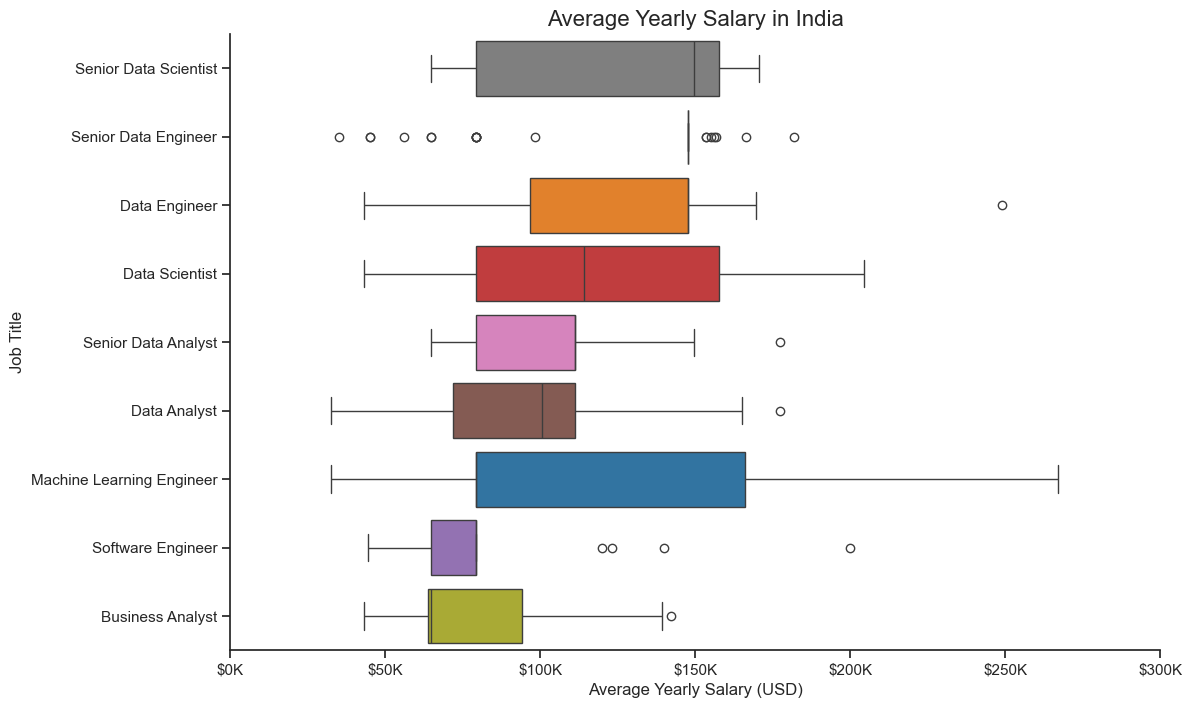

In [55]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.boxplot(data=df_top_jobs, x='salary_year_avg', y='job_title_short', order=top_jobs, hue='job_title_short', palette='tab10')
sns.set_theme(style="whitegrid")
sns.despine()  # Use a color palette with 10 distinct colors

plt.xlim(0, 300000) # Set x-axis limits to focus on the range of salaries
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlabel('Average Yearly Salary (USD)')
plt.ylabel('Job Title')
plt.title('Average Yearly Salary in India', fontsize=16)
plt.show()

In [45]:
# Filter the DataFrame for Data Analyst jobs in India
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop rows with missing values in the 'salary_year_avg' column
df_DA_India = df_DA_India.dropna(subset=['salary_year_avg'])

df_DA_India = df_DA_India.explode('job_skills')

df_DA_top_pay = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False).head(10)

df_DA_top_skills = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

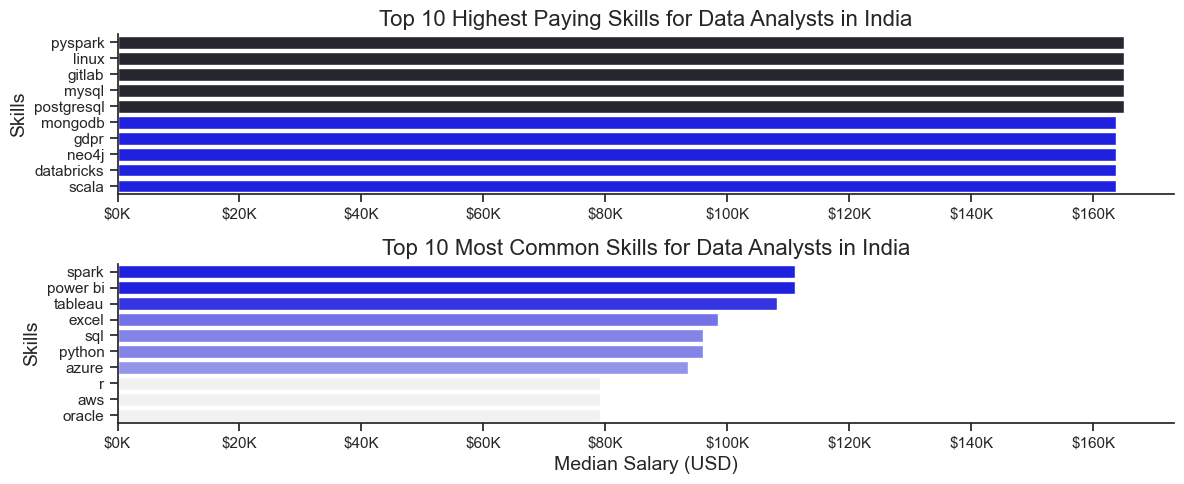

In [54]:
fig, ax = plt.subplots(2, 1, figsize=(12, 5))

sns.set_theme(style="ticks")

#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)    , palette='viridis'

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:blue_r', legend=False)

sns.despine()  # Use a color palette with 10 distinct colors

ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts in India', fontsize=16)
ax[0].set_xlabel('')
ax[0].set_ylabel('Skills', fontsize=14)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

#df_DA_top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)

sns.barplot(data=df_DA_top_skills, x='median', y=df_DA_top_skills.index, ax=ax[1], hue='median', palette='light:blue', legend=False)

ax[1].set_title('Top 10 Most Common Skills for Data Analysts in India', fontsize=16)
ax[1].set_xlabel('Median Salary (USD)', fontsize=14)
ax[1].set_ylabel('Skills', fontsize=14)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()
plt.show()